Preview of dataset:
  show_id     type  ... content_age_mm Content_Type
0      s1    Movie  ...       0.010417     Original
1      s2  TV Show  ...       0.000000     Licensed
2      s3  TV Show  ...       0.000000     Licensed
3      s4  TV Show  ...       0.000000     Licensed
4      s5  TV Show  ...       0.000000     Licensed

[5 rows x 72 columns]


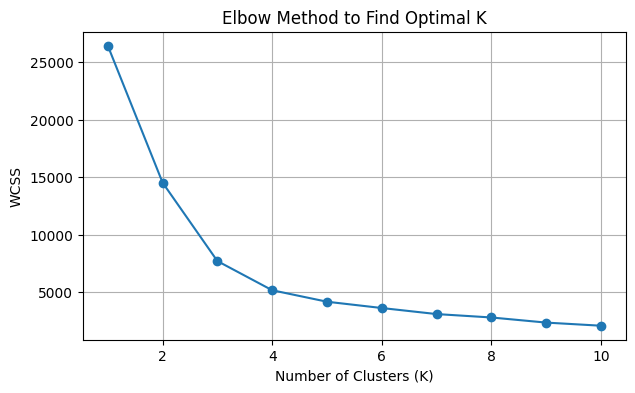


Cluster assigned successfully!


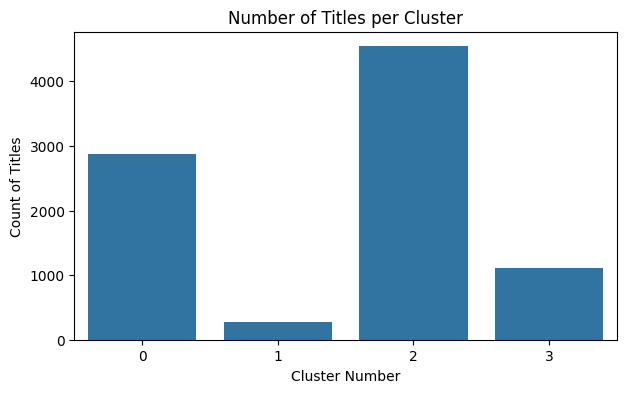

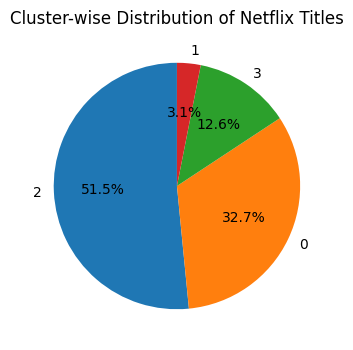

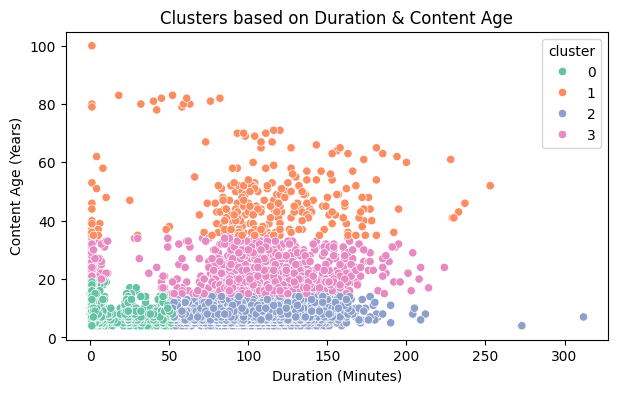


Clustered dataset saved as netflix_clustered_dataset1.csv


In [0]:

# 1. Load Feature-Engineered Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("netflix_feature_engineered2.csv")

print("Preview of dataset:")
print(df.head())



# 2. Select Features for Clustering
features = df[['content_age', 'duration_num', 'release_year']]

# Scaling Features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)



# 3. Elbow Method → Find Optimal K
wcss = []  # Within Cluster Sum of Squares

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_features)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method to Find Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()


# 4. Apply K-Means Clustering
k = 4  # <-- choose based on elbow result
kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)

print("\nCluster assigned successfully!")

# 5. Visualization 1:
# BAR CHART — Cluster Number vs Number of Titles
plt.figure(figsize=(7,4))
sns.countplot(x='cluster', data=df)
plt.title("Number of Titles per Cluster")
plt.xlabel("Cluster Number")
plt.ylabel("Count of Titles")
plt.show()


# 6. Visualization 2:
# PIE CHART — Cluster-wise Distribution of Titles
cluster_counts = df['cluster'].value_counts()

plt.figure(figsize=(7,4))
plt.pie(cluster_counts, labels=cluster_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Cluster-wise Distribution of Netflix Titles")
plt.show()



# 7. Visualization 3:
# SCATTERPLOT — How clusters group content
plt.figure(figsize=(7,4))
sns.scatterplot(
    x=df['duration_num'],
    y=df['content_age'],
    hue=df['cluster'],
    palette="Set2"
)
plt.title("Clusters based on Duration & Content Age")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Content Age (Years)")
plt.show()


# 8. Save the clustered dataset
df.to_csv("netflix_clustered_dataset1.csv", index=False)
print("\nClustered dataset saved as netflix_clustered_dataset1.csv")



Selected Features for Classification: ['release_year', 'duration_num', 'rating', 'listed_in', 'country']

Label Encoding completed for categorical columns.

Train-Test Split Done.
Training Set: (7045, 5)  | Testing Set: (1762, 5)

Feature Scaling Completed.

Model Accuracy: 99.94 %

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1227
           1       1.00      1.00      1.00       535

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



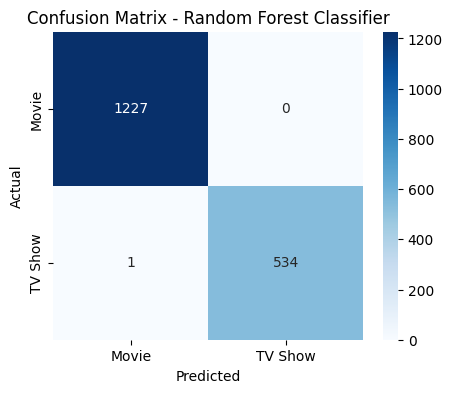


Feature Importance:
 duration_num    0.781046
listed_in       0.171290
rating          0.033828
release_year    0.007201
country         0.006635
dtype: float64


/home/spark-632a457e-46b4-40d5-a4d9-34/.ipykernel/1600/command-6111881128057059-3371662330:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')


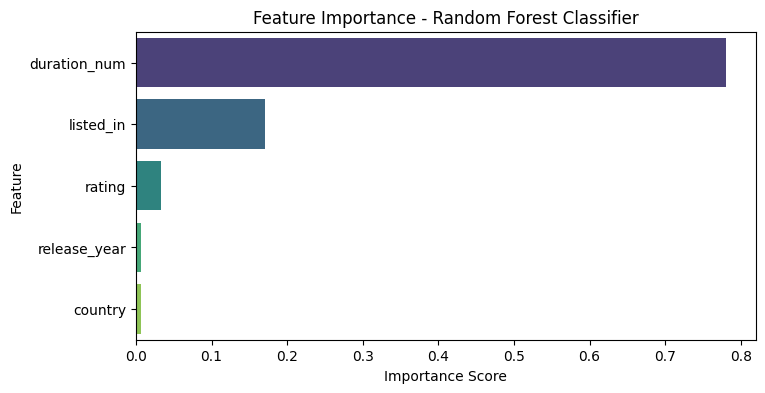

In [0]:
# CLASSIFICATION ON NETFLIX DATASET
# Step 1: Import libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Select features and target
target = 'type'
features = ['release_year', 'duration_num', 'rating', 'listed_in', 'country']

# Keep only columns that exist in the dataset
features = [col for col in features if col in df.columns]
print("\nSelected Features for Classification:", features)

df_class = df[features + [target]].dropna().copy()

# Step 3: Encode categorical columns
le = LabelEncoder()
for col in df_class.columns:
    if df_class[col].dtype == 'object':
        df_class[col] = le.fit_transform(df_class[col].astype(str))

print("\nLabel Encoding completed for categorical columns.")

# Step 4: Split features and target
X = df_class[features]
y = df_class[target]

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTrain-Test Split Done.")
print("Training Set:", X_train.shape, " | Testing Set:", X_test.shape)

# Step 6: Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature Scaling Completed.")

# Step 7: Train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Step 8: Model Evaluation
y_pred = rf.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Movie','TV Show'], yticklabels=['Movie','TV Show'])
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Step 9: Feature Importance
feature_importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature Importance:\n", feature_importance)

plt.figure(figsize=(8,4))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')
plt.title('Feature Importance - Random Forest Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()
